# Space-time: predict an edge from its history

How can neighboring dates help price the integer decision in one image?

We start with numbers that can be checked by hand, draw the algorithm’s decision, then run the public API on data with known truth. All phase values are in radians unless stated otherwise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import parvaneh as pv
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def W(x): return (np.asarray(x)+np.pi) % (2*np.pi)-np.pi
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+
        '|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(map(str,r))+' |' for r in rows)))
def images(arrays, titles, cmap='viridis'):
    fig,axes=plt.subplots(1,len(arrays),figsize=(4*len(arrays),3.4),constrained_layout=True)
    for ax,a,title in zip(np.atleast_1d(axes),arrays,titles):
        im=ax.imshow(a,cmap=cmap); ax.set(title=title,xlabel='column',ylabel='row')
        fig.colorbar(im,ax=ax,shrink=.75)
    plt.show()
def align(u,t): return u-np.mean(u-t)
def scene():
    y,x=np.mgrid[0:18,0:22]
    truth=.38*x+.22*y+1.4*np.exp(-((x-12)**2+(y-8)**2)/25)
    patch=(x>=8)&(x<=14)&(y>=5)&(y<=12)
    rng=np.random.default_rng(21)
    phase=W(truth+rng.normal(size=truth.shape)*np.where(patch,1.35,.06))
    confidence=np.where(patch,.2,1.)
    return truth,phase,confidence
def report(u,t,w):
    assert u.shape==t.shape and np.isfinite(u).all()
    table(['Quantity','Measured value'],[
        ['Aligned RMSE (rad)',f'{pv.rmse_aligned(u,t):.6f}'],
        ['Raw max wrapped difference from input (rad)',f'{np.max(np.abs(W(u-w))):.6f}']])
    images([align(u,t),align(u,t)-t],['Aligned reconstruction (rad)','Error against truth (rad)'])

## 1 · Work through the model

For an edge observed at times $t_j$, Gaussian weights around $t_i$ are
$a_{ij}\propto\exp(-(t_i-t_j)^2/(2\tau^2))$. Normalize them to sum to one.
Average phases on the unit circle: $m_i=\sum_j a_{ij}e^{ig_j}$.
Its angle is a local reference; fit wrapped deviations around that reference
with a weighted line to estimate a prediction and uncertainty.

1. Extract spatial wrapped steps for every date.
2. Build temporal predictions and error variances for each spatial edge.
3. Price integer corrections using these priors.
4. Solve each date's spatial network and integrate it.

This uses a stack but does not add temporal edges to the spatial flow graph.
Each output image still has its own phase-offset ambiguity.

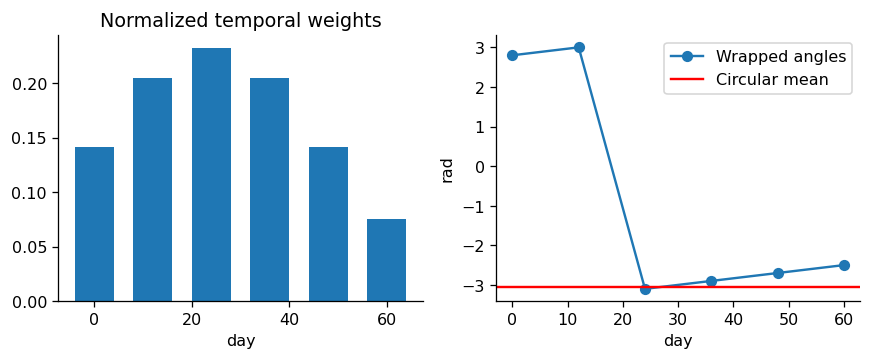

Arithmetic mean: -0.9 circular mean: -3.049747013550137


In [2]:
days=np.arange(6)*12.; tau=24.; angles=np.array([2.8,3.,-3.1,-2.9,-2.7,-2.5])
weights=np.exp(-(days-days[2])**2/(2*tau*tau)); weights/=weights.sum()
mean=np.angle(np.sum(weights*np.exp(1j*angles)))
fig,axes=plt.subplots(1,2,figsize=(9,3))
axes[0].bar(days,weights,width=8); axes[0].set(title='Normalized temporal weights',xlabel='day')
axes[1].plot(days,angles,'o-',label='Wrapped angles'); axes[1].axhline(mean,color='red',label='Circular mean')
axes[1].set(xlabel='day',ylabel='rad'); axes[1].legend(); plt.show()
print('Arithmetic mean:',angles.mean(),'circular mean:',mean)

## 2 · Read the calculation

The arithmetic mean can fall near zero even when measurements cluster near
$\pi$. A circular mean avoids that branch-cut artifact. The actual temporal
prior additionally fits a local line and estimates variance; the two-line mean
calculation is just the first stage, not a substitute implementation.

## 3 · Run the implementation

The seed and input sizes below are fixed. A low objective or a converged solver means the chosen mathematical problem was solved; it does not prove the physical phase was recovered.

SpaceTimeInfo(backend='space-time-flow', mode='interferogram', shape=(8, 10), observations=6, epochs=6, pixels=480, nodes=80, edges=142, cycles=63, residues=0, components=1, gated_edges=0, masked_edges=0, max_jump=0, objective=60.863394159982164, objective_per_observation=array([ 5.00548504, 13.11397969, 13.68903445, 13.49684824, 11.80686925,
        3.7511775 ]), time_win=24.0, noise_gate=1.3, min_variance=0.0025, augmentations=0, proven=True)


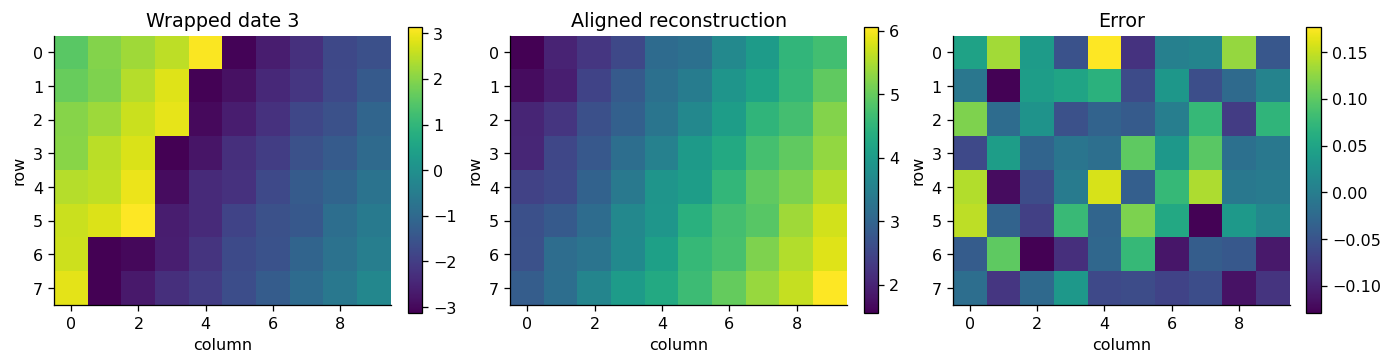

In [3]:
days=np.arange(6)*12.; y,x=np.mgrid[0:8,0:10]
truth=np.array([(.3+.02*i)*x+.2*y+.5*i for i in range(6)])
phase=W(truth+np.random.default_rng(8).normal(0,.08,truth.shape))
params=pv.SpaceTimeParams(time_win=24)
u,info=pv.space_time_unwrap(phase,days,params=params,return_info=True)
print(info)
images([phase[3],align(u[3],truth[3]),align(u[3],truth[3])-truth[3]],['Wrapped date 3','Aligned reconstruction','Error'])

## 4 · Change one choice and measure its effect

This controlled experiment changes a solver setting, data condition, or reference calculation. Compare the measured values before drawing a conclusion.

| Window (days) | Mean per-image aligned RMSE |
|---|---|
| 12.0 | 0.0809 |
| 48.0 | 0.0809 |

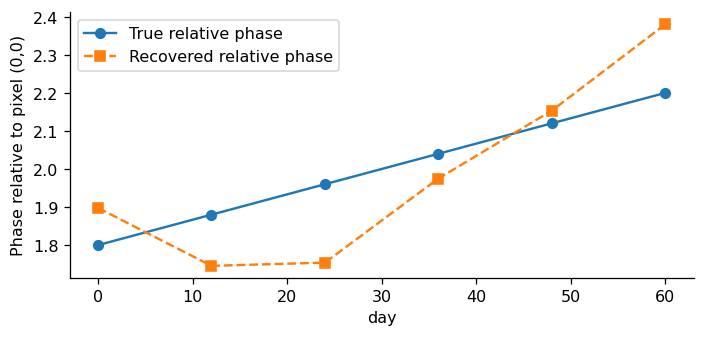

In [4]:
rows=[]
for window in [12.,48.]:
    value=pv.space_time_unwrap(phase,days,params=pv.SpaceTimeParams(time_win=window))
    errors=[pv.rmse_aligned(a,b) for a,b in zip(value,truth)]
    rows.append([window,f'{np.mean(errors):.4f}'])
table(['Window (days)','Mean per-image aligned RMSE'],rows)
fig,ax=plt.subplots(figsize=(7,3))
ax.plot(days,truth[:,3,4]-truth[:,0,0],'o-',label='True relative phase')
ax.plot(days,u[:,3,4]-u[:,0,0],'s--',label='Recovered relative phase')
ax.set(xlabel='day',ylabel='Phase relative to pixel (0,0)'); ax.legend(); plt.show()

## 5 · Interpretation and limits

The input shape is (observations, rows, columns), and acquisition days must
increase. Longer smoothing windows assume slower temporal change; real rapid
deformation may violate that assumption. Time does not fix per-image constants,
so the plot uses a spatial reference and the metric aligns each frame.
The alternative `design` input represents interferograms through an epoch design
matrix; it is a different input contract, not a fourth spatial axis.

## Continue exploring

Rerun with another seed or a larger phase step. Predict which assumption fails first, then inspect the result and report. The method’s output convention and masks matter as much as its RMSE.

Implementation: [`space_time.py`](../src/parvaneh/space_time.py). See the [API reference](../docs/api.md), [notebook index](../docs/notebooks.md), [mathematical derivations](../docs/mathematics.md), and [bibliography](../docs/references.md) for further reading. These examples describe the current implementation, including its limitations; they are not claims of numerical identity with external software.